# Analysis Batching

## Setup

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

metrics_dir = Path("../results/metrics")
json_files = sorted(metrics_dir.glob("batch_size_*.json"))

records = []
for path in json_files:
    with open(path) as f:
        d = json.load(f)
    records.append(d)

records = sorted(records, key=lambda x: x['batch_size'])

batch_sizes    = [r['batch_size']         for r in records]
throughput_tps = [r['throughput_p50_tps'] for r in records]
latency_p50    = [r['latency_p50_ms']     for r in records]
latency_p99    = [r['latency_p99_ms']     for r in records]
latency_mean   = [r['latency_mean_ms']    for r in records]

speedup    = [tps / throughput_tps[0] for tps in throughput_tps]
efficiency = [tps / (b * throughput_tps[0]) * 100
              for b, tps in zip(batch_sizes, throughput_tps)]

print("Batching data from JSON:")
print(f"{'batch':>6} {'tps_p50':>10} {'lat_p50':>10} "
      f"{'lat_p99':>10} {'speedup':>8} {'eff':>8}")
for b, tps, lp50, lp99, sp, eff in zip(batch_sizes, throughput_tps,
                                         latency_p50, latency_p99,
                                         speedup, efficiency):
    print(f"{b:>6} {tps:>10.1f} {lp50:>10.1f}ms "
          f"{lp99:>10.1f}ms {sp:>8.1f}x {eff:>7.1f}%")

Batching data from JSON:
 batch    tps_p50    lat_p50    lat_p99  speedup      eff
     1       32.2     1555.1ms     1582.3ms      1.0x   100.0%
     2       51.1      979.0ms     1015.2ms      1.6x    79.4%
     4      125.0      400.0ms      417.7ms      3.9x    97.2%
     8      246.5      202.8ms      225.5ms      7.7x    95.8%
    16      432.6      115.6ms      133.0ms     13.5x    84.1%
    32      897.9       55.7ms       58.2ms     27.9x    87.3%


## Throughput vs Batch Size

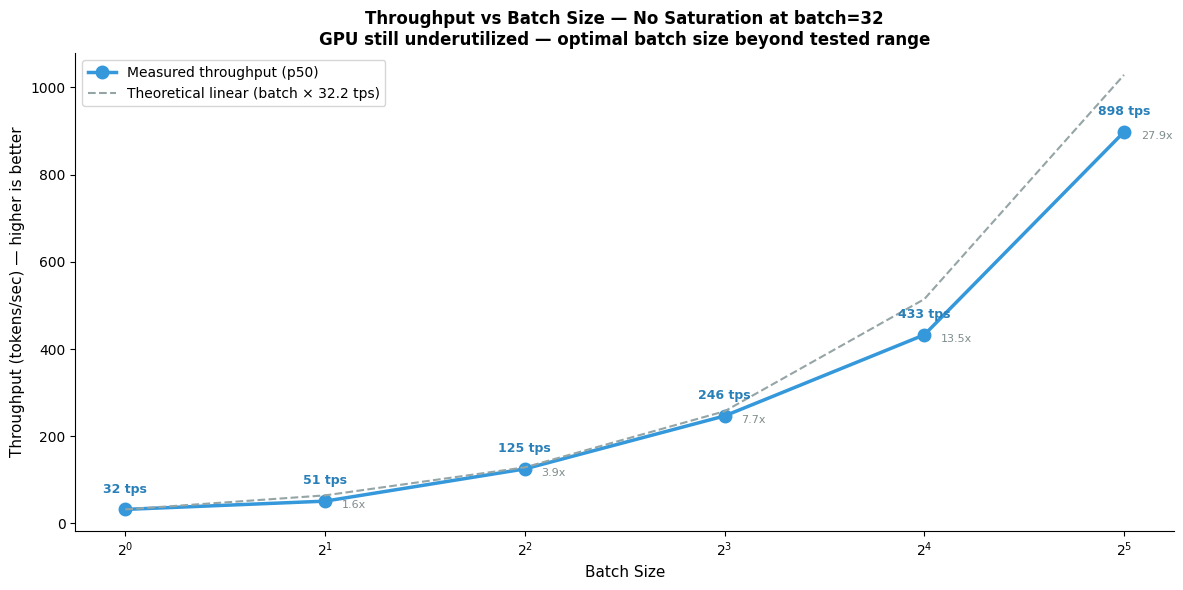

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(batch_sizes, throughput_tps,
        color="#3498db", marker="o", linewidth=2.5,
        markersize=9, label="Measured throughput (p50)")

theoretical_linear = [b * throughput_tps[0] for b in batch_sizes]
ax.plot(batch_sizes, theoretical_linear,
        color="#95a5a6", linewidth=1.5, linestyle="--",
        label=f"Theoretical linear (batch × {throughput_tps[0]:.1f} tps)")

for b, tps in zip(batch_sizes, throughput_tps):
    ax.annotate(f"{tps:.0f} tps",
                (b, tps), textcoords="offset points",
                xytext=(0, 12), ha="center",
                fontsize=9, fontweight="bold", color="#2980b9")

for b, tps, sp in zip(batch_sizes[1:], throughput_tps[1:], speedup[1:]):
    ax.annotate(f"{sp:.1f}x",
                (b, tps), textcoords="offset points",
                xytext=(12, -5), ha="left",
                fontsize=8, color="#7f8c8d")

ax.set_xlabel("Batch Size", fontsize=11)
ax.set_ylabel("Throughput (tokens/sec) — higher is better", fontsize=11)
ax.set_title("Throughput vs Batch Size — No Saturation at batch=32\n"
             "GPU still underutilized — optimal batch size beyond tested range",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xscale("log", base=2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
Path("../results/figures/batching").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/batching/throughput_vs_batch_size.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Latency vs Batch Size dengan P50 dan P99

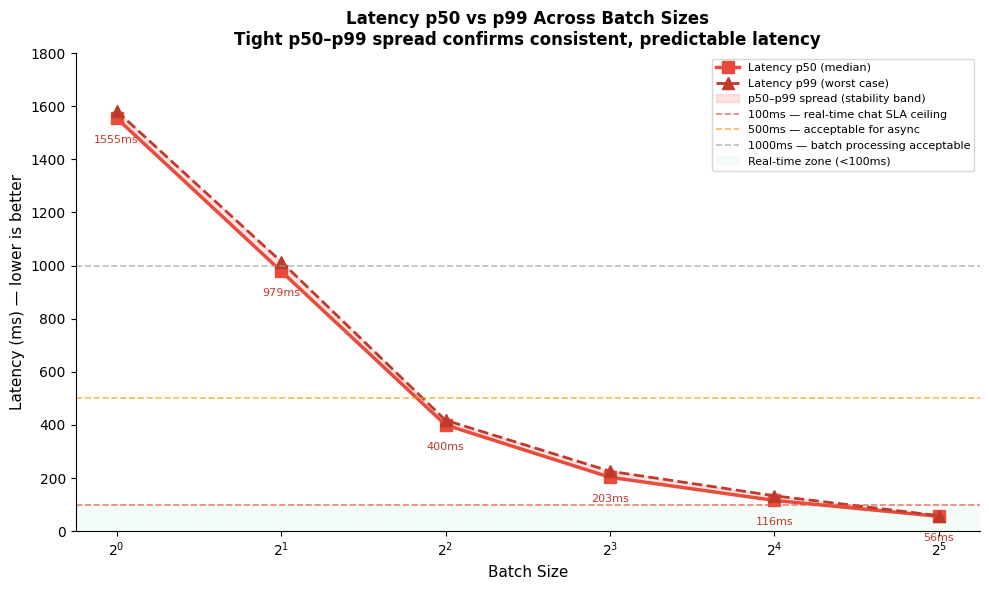


Latency spread (p99 - p50) per batch:
  batch= 1: p50=1555.1ms, p99=1582.3ms, spread=27.2ms (1.7%)
  batch= 2: p50=979.0ms, p99=1015.2ms, spread=36.2ms (3.7%)
  batch= 4: p50=400.0ms, p99=417.7ms, spread=17.7ms (4.4%)
  batch= 8: p50=202.8ms, p99=225.5ms, spread=22.6ms (11.2%)
  batch=16: p50=115.6ms, p99=133.0ms, spread=17.4ms (15.1%)
  batch=32: p50=55.7ms, p99=58.2ms, spread=2.5ms (4.5%)


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(batch_sizes, latency_p50,
        color="#e74c3c", marker="s", linewidth=2.5,
        markersize=9, label="Latency p50 (median)")

ax.plot(batch_sizes, latency_p99,
        color="#c0392b", marker="^", linewidth=2,
        markersize=8, linestyle="--", label="Latency p99 (worst case)")

ax.fill_between(batch_sizes, latency_p50, latency_p99,
                alpha=0.15, color="#e74c3c",
                label="p50–p99 spread (stability band)")

for b, lp50, lp99 in zip(batch_sizes, latency_p50, latency_p99):
    ax.annotate(f"{lp50:.0f}ms",
                (b, lp50), textcoords="offset points",
                xytext=(0, -18), ha="center",
                fontsize=8, color="#c0392b")

sla_thresholds = [
    (100,  "#e74c3c", "100ms — real-time chat SLA ceiling"),
    (500,  "#f39c12", "500ms — acceptable for async"),
    (1000, "#95a5a6", "1000ms — batch processing acceptable"),
]
for threshold, color, label in sla_thresholds:
    ax.axhline(y=threshold, color=color, linestyle="--",
               linewidth=1.2, alpha=0.7, label=label)

ax.axhspan(0, 100, alpha=0.05, color="#2ecc71",
           label="Real-time zone (<100ms)")

ax.set_xlabel("Batch Size", fontsize=11)
ax.set_ylabel("Latency (ms) — lower is better", fontsize=11)
ax.set_title("Latency p50 vs p99 Across Batch Sizes\n"
             "Tight p50–p99 spread confirms consistent, predictable latency",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=8, loc="upper right")
ax.set_xscale("log", base=2)
ax.set_ylim(0, 1800)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/batching/latency_vs_batch_size.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nLatency spread (p99 - p50) per batch:")
for b, lp50, lp99 in zip(batch_sizes, latency_p50, latency_p99):
    spread = lp99 - lp50
    pct    = (spread / lp50) * 100
    print(f"  batch={b:2d}: p50={lp50:.1f}ms, "
          f"p99={lp99:.1f}ms, spread={spread:.1f}ms ({pct:.1f}%)")

## Throughput-Latency Trade-off Scatter

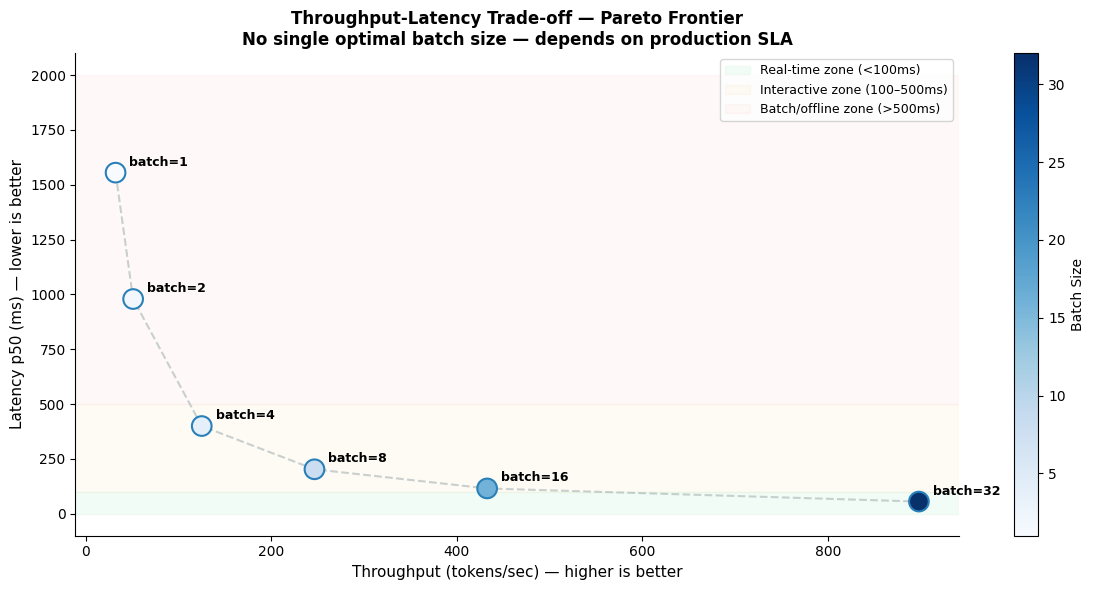


Pareto analysis:
  For real-time chat (latency < 100ms):
    batch=32: 898 tps, 56ms

  Max throughput:
    batch=32: 898 tps, 56ms


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(throughput_tps, latency_p50,
                     c=batch_sizes, cmap="Blues",
                     s=200, zorder=5,
                     edgecolors="#2980b9", linewidth=1.5)

ax.plot(throughput_tps, latency_p50,
        color="#95a5a6", linewidth=1.5,
        linestyle="--", alpha=0.5, zorder=4)

for b, tps, lat in zip(batch_sizes, throughput_tps, latency_p50):
    ax.annotate(f"batch={b}",
                (tps, lat), textcoords="offset points",
                xytext=(10, 5), ha="left",
                fontsize=9, fontweight="bold")

ax.axhspan(0, 100, alpha=0.06, color="#2ecc71",
           label="Real-time zone (<100ms)")
ax.axhspan(100, 500, alpha=0.04, color="#f39c12",
           label="Interactive zone (100–500ms)")
ax.axhspan(500, 2000, alpha=0.03, color="#e74c3c",
           label="Batch/offline zone (>500ms)")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Batch Size", fontsize=10)

ax.set_xlabel("Throughput (tokens/sec) — higher is better", fontsize=11)
ax.set_ylabel("Latency p50 (ms) — lower is better", fontsize=11)
ax.set_title("Throughput-Latency Trade-off — Pareto Frontier\n"
             "No single optimal batch size — depends on production SLA",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9, loc="upper right")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/batching/throughput_latency_tradeoff.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nPareto analysis:")
print("  For real-time chat (latency < 100ms):")
for b, tps, lat in zip(batch_sizes, throughput_tps, latency_p50):
    if lat <= 100:
        print(f"    batch={b}: {tps:.0f} tps, {lat:.0f}ms")
print("\n  Max throughput:")
max_idx = throughput_tps.index(max(throughput_tps))
print(f"    batch={batch_sizes[max_idx]}: "
      f"{throughput_tps[max_idx]:.0f} tps, "
      f"{latency_p50[max_idx]:.0f}ms")

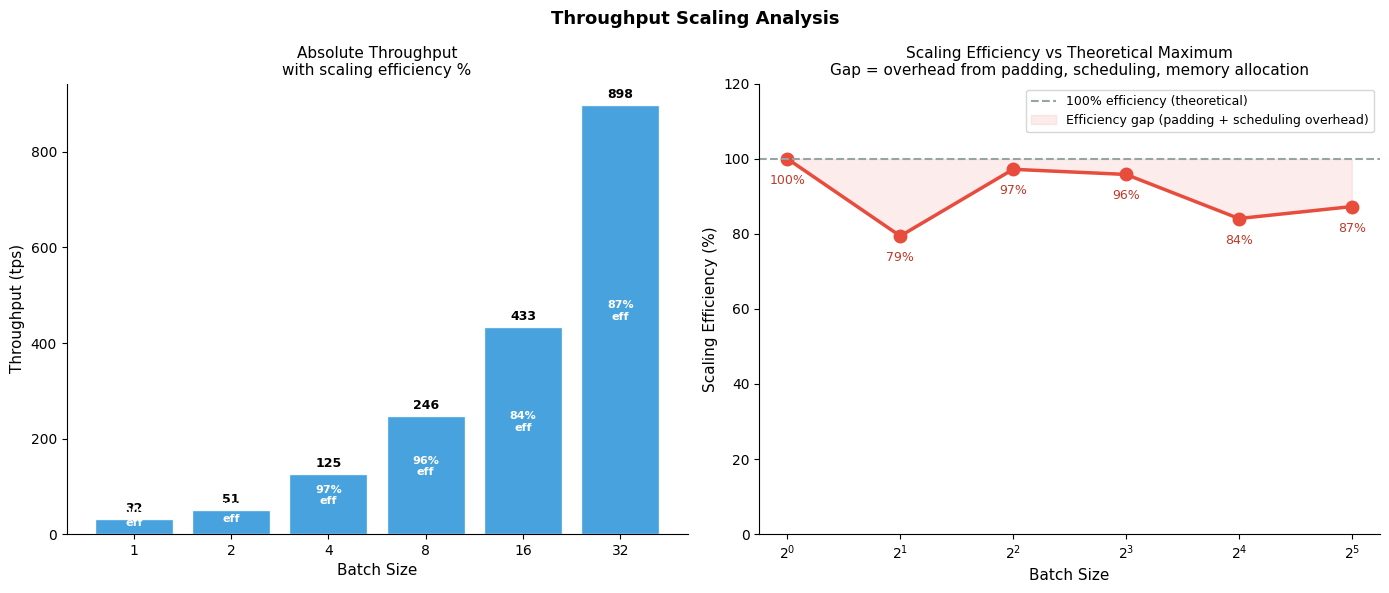


Scaling efficiency:
  batch= 1: 32.2 tps, efficiency=100.0%
  batch= 2: 51.1 tps, efficiency=79.4%
  batch= 4: 125.0 tps, efficiency=97.2%
  batch= 8: 246.5 tps, efficiency=95.8%
  batch=16: 432.6 tps, efficiency=84.1%
  batch=32: 897.9 tps, efficiency=87.3%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Throughput Scaling Analysis",
             fontsize=13, fontweight="bold")

bars = axes[0].bar(range(len(batch_sizes)), throughput_tps,
                   color="#3498db", edgecolor="white", alpha=0.9)

for i, (b, tps, eff) in enumerate(zip(batch_sizes,
                                       throughput_tps, efficiency)):
    axes[0].text(i, tps + 15, f"{tps:.0f}",
                 ha="center", fontsize=9, fontweight="bold")
    axes[0].text(i, tps/2, f"{eff:.0f}%\neff",
                 ha="center", fontsize=8,
                 color="white", fontweight="bold")

axes[0].set_xticks(range(len(batch_sizes)))
axes[0].set_xticklabels([str(b) for b in batch_sizes])
axes[0].set_xlabel("Batch Size", fontsize=11)
axes[0].set_ylabel("Throughput (tps)", fontsize=11)
axes[0].set_title("Absolute Throughput\nwith scaling efficiency %",
                  fontsize=11)
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

axes[1].plot(batch_sizes, efficiency,
             color="#e74c3c", marker="o", linewidth=2.5, markersize=9)
axes[1].axhline(y=100, color="#95a5a6", linestyle="--",
                linewidth=1.5, label="100% efficiency (theoretical)")
axes[1].fill_between(batch_sizes, efficiency, 100,
                     alpha=0.1, color="#e74c3c",
                     label="Efficiency gap (padding + scheduling overhead)")

for b, eff in zip(batch_sizes, efficiency):
    axes[1].annotate(f"{eff:.0f}%",
                     (b, eff), textcoords="offset points",
                     xytext=(0, -18), ha="center",
                     fontsize=9, color="#c0392b")

axes[1].set_xlabel("Batch Size", fontsize=11)
axes[1].set_ylabel("Scaling Efficiency (%)", fontsize=11)
axes[1].set_title("Scaling Efficiency vs Theoretical Maximum\n"
                  "Gap = overhead from padding, scheduling, memory allocation",
                  fontsize=11)
axes[1].set_xscale("log", base=2)
axes[1].set_ylim(0, 120)
axes[1].legend(fontsize=9)
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/batching/throughput_scaling_efficiency.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nScaling efficiency:")
for b, tps, eff in zip(batch_sizes, throughput_tps, efficiency):
    print(f"  batch={b:2d}: {tps:.1f} tps, efficiency={eff:.1f}%")